# Performance Analysis (perf_001)

Wall-clock runtimes and scaling analysis for the 16 representative cases
across worker counts W = 1, 2, 4, 8, 16.

In [1]:
from pathlib import Path

import msgpack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="paper", font_scale=1.75)

from load_results import load_results_raw
from ship_routing.app import RoutingResult
from experiment_params import REPRESENTATIVE_JOURNEYS, REPRESENTATIVE_CASES

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

## 1. Load results

In [2]:
result_files = sorted(Path("../results").glob("perf_*.msgpack"))
print(f"Found {len(result_files)} result files")

# Load all into a single dict, dedup by key
raw = {}
for f in result_files:
    with open(f, "rb") as fh:
        raw.update(msgpack.unpack(fh, raw=False))
print(f"Unique results: {len(raw)}")

Found 562 result files
Unique results: 240


In [3]:
# Parse keys into structured records
# Key format: perf:c{case}:r{replica}:w{workers}:seed{seed}
records = []
for key, value in tqdm(raw.items(), desc="parsing"):
    parts = key.split(":")
    case_idx = int(parts[1][1:])
    replica_idx = int(parts[2][1:])
    workers = int(parts[3][1:])
    seed = int(parts[4][4:])

    rr = RoutingResult.from_msgpack(value)
    df = rr.logs.to_dataframe()
    t0 = df.timestamp.min()
    t1 = df.timestamp.max()

    # Stage boundaries from log timestamps
    stages = df.groupby("stage").timestamp.agg(["min", "max"])
    total_s = (t1 - t0).total_seconds()
    t_load = (stages.loc["initialization", "min"] - stages.loc["load_forcing", "min"]).total_seconds()
    t_init = (stages.loc["warmup", "min"] - stages.loc["initialization", "min"]).total_seconds()
    t_warmup = (stages.loc["ga_mutation", "min"] - stages.loc["warmup", "min"]).total_seconds()
    t_genetic = (stages.loc["gradient_polishing", "min"] - stages.loc["ga_mutation", "min"]).total_seconds()
    t_gd = (stages.loc["gd_iteration", "max"] - stages.loc["gradient_polishing", "min"]).total_seconds()

    # Index REPRESENTATIVE_JOURNEYS (not REPRESENTATIVE_CASES): the perf runs are
    # generated from REPRESENTATIVE_JOURNEYS order (see run_perf_benchmark._get_config),
    # which differs from the REPRESENTATIVE_CASES list order.
    rc = REPRESENTATIVE_JOURNEYS[case_idx]
    direction = "E" if "forward" in rc.name else "W"
    month_label = "Aug" if int(rc.time_start[5:7]) == 8 else "Jan"

    records.append({
        "case_idx": case_idx,
        "replica_idx": replica_idx,
        "workers": str(workers),
        "speed": f"{rc.speed_knots:.0f} kn",
        "case": f"{month_label} 2021 {direction}",
        "total_min": total_s / 60,
        "t_load": t_load, "t_init": t_init, "t_warmup": t_warmup,
        "t_genetic": t_genetic, "t_gd": t_gd,
    })

perf = pd.DataFrame.from_records(records)
perf["workers"] = pd.Categorical(perf["workers"], categories=["1", "2", "4", "8", "16"], ordered=True)
print(f"{len(perf)} records loaded")

parsing:   0%|          | 0/240 [00:00<?, ?it/s]

240 records loaded


In [4]:
# Coverage check
coverage = perf.groupby(["case", "speed", "workers"]).replica_idx.count().unstack(fill_value=0)
print("Replicas per (case, speed, workers):")
coverage

Replicas per (case, speed, workers):


/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_60734/704484001.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coverage = perf.groupby(["case", "speed", "workers"]).replica_idx.count().unstack(fill_value=0)


workers           1  2  4  8  16
case       speed                
Aug 2021 E 12 kn  3  3  3  3   3
           16 kn  3  3  3  3   3
           20 kn  3  3  3  3   3
           8 kn   3  3  3  3   3
Aug 2021 W 12 kn  3  3  3  3   3
           16 kn  3  3  3  3   3
           20 kn  3  3  3  3   3
           8 kn   3  3  3  3   3
Jan 2021 E 12 kn  3  3  3  3   3
           16 kn  3  3  3  3   3
           20 kn  3  3  3  3   3
           8 kn   3  3  3  3   3
Jan 2021 W 12 kn  3  3  3  3   3
           16 kn  3  3  3  3   3
           20 kn  3  3  3  3   3
           8 kn   3  3  3  3   3

## 2. Wall-clock time vs workers

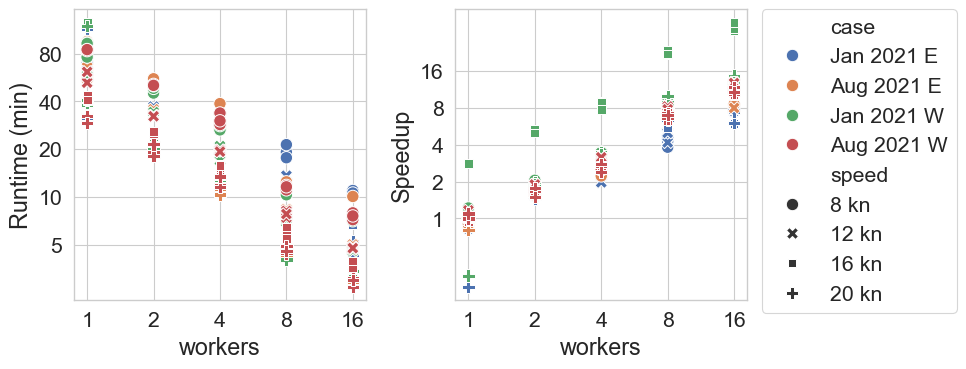

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(data=perf, x="workers", y="total_min", hue="case", style="speed",
                s=80, ax=ax1, legend=False)
ax1.set_ylabel("Runtime (min)")
ax1.set_yscale("log")
ax1.set_yticks([5, 10, 20, 40, 80])
ax1.set_yticklabels([5, 10, 20, 40, 80])

# Speedup
t1_median = (
    perf[perf.workers == "1"]
    .groupby(["case", "speed"])
    .total_min.median()
    .rename("t1_median")
)
perf_sp = perf.merge(t1_median, on=["case", "speed"])
perf_sp["speedup"] = perf_sp.t1_median / perf_sp.total_min

sns.scatterplot(data=perf_sp, x="workers", y="speedup", hue="case", style="speed",
                s=80, ax=ax2)
ax2.set_ylabel("Speedup")
ax2.set_yscale("log")
ax2.set_yticks([1, 2, 4, 8, 16])
ax2.set_yticklabels([1, 2, 4, 8, 16])

# Single legend from ax2, placed outside
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

fig.tight_layout()
fig.savefig(FIG_DIR / "010_perf_combined.png", dpi=150, bbox_inches="tight")
fig.savefig(FIG_DIR / "010_perf_combined.pdf", bbox_inches="tight")
plt.show()

## 3. Stage breakdown

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_60734/3737220552.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stage_median = perf.groupby(["case", "speed", "workers"])[stage_cols].median()


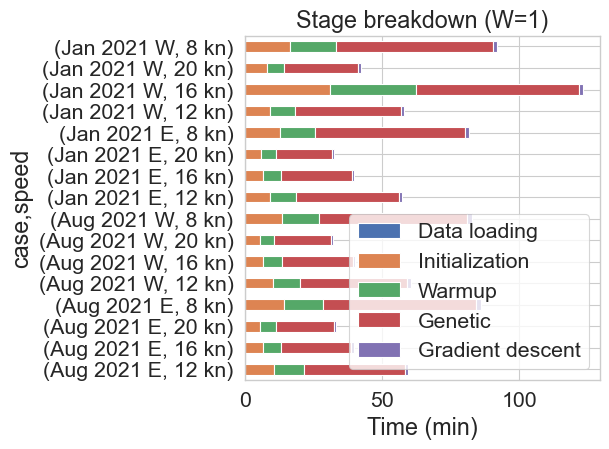

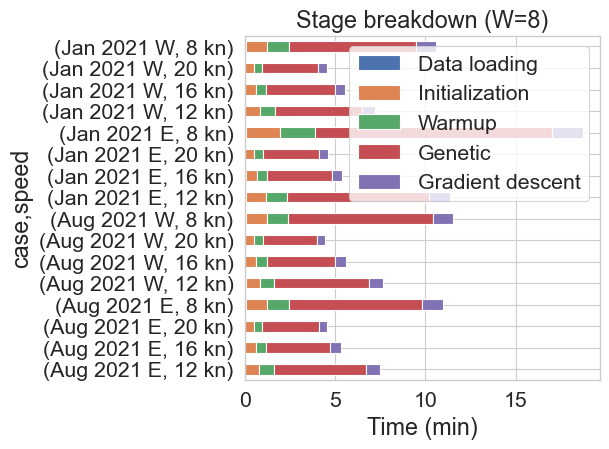

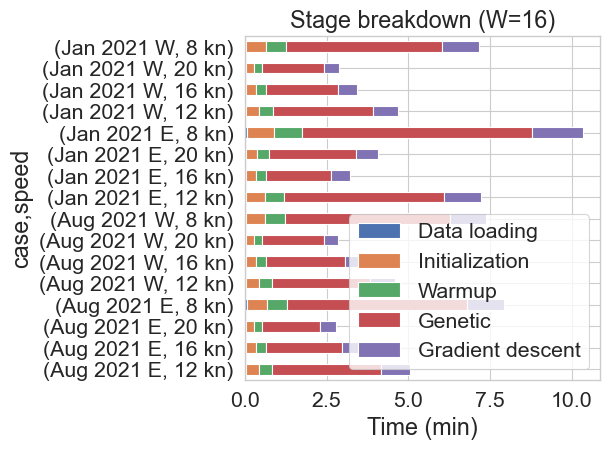

In [6]:
stage_cols = ["t_load", "t_init", "t_warmup", "t_genetic", "t_gd"]
stage_labels = ["Data loading", "Initialization", "Warmup", "Genetic", "Gradient descent"]

stage_median = perf.groupby(["case", "speed", "workers"])[stage_cols].median()

for w in ["1", "8", "16"]:
    sub = stage_median.xs(w, level="workers") / 60
    sub.columns = stage_labels
    sub.plot.barh(stacked=True, title=f"Stage breakdown (W={w})", xlabel="Time (min)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"010_stage_breakdown_w{int(w):02d}.png", dpi=150)
    plt.show()

## 4. Speedup and parallel efficiency

In [7]:
# Speedup already computed and plotted in combined figure above

In [8]:
# Summary tables
pivot = perf.groupby(["case", "speed", "workers"]).total_min.median().reset_index()
pivot_wide = pivot.pivot(index=["case", "speed"], columns="workers", values="total_min")
print("Median runtime (min):")
display(pivot_wide.round(1))

Median runtime (min):


/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_60734/246614587.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = perf.groupby(["case", "speed", "workers"]).total_min.median().reset_index()


workers               1     2     4     8    16
case       speed                               
Aug 2021 E 12 kn   59.7  33.3  19.9   7.6   5.0
           16 kn   39.9  24.6  14.7   5.4   3.8
           20 kn   33.3  19.6  11.3   4.7   2.8
           8 kn    86.4  48.2  33.2  11.0   8.0
Aug 2021 W 12 kn   61.2  32.5  19.4   7.8   4.8
           16 kn   40.8  25.4  15.4   5.8   3.8
           20 kn   32.2  19.2  12.0   4.6   3.0
           8 kn    84.4  50.5  30.2  11.6   7.6
Jan 2021 E 12 kn   57.1  33.7  20.7  11.4   7.3
           16 kn   39.9  25.0  12.6   5.6   3.4
           20 kn   31.8  19.7  11.6   4.8   4.3
           8 kn    81.8  49.8  27.5  19.2  10.6
Jan 2021 W 12 kn   58.4  33.7  19.6   7.2   4.7
           16 kn  123.7  23.2  13.8   5.6   3.4
           20 kn   40.7  21.4  12.1   4.6   3.1
           8 kn    92.7  48.4  28.2  10.6   7.4